Previsão do Preço de Fecho das Ações da Netflix

Este trabalho tem como objetivo desenvolver um modelo de Aprendizagem Automática Supervisionada (regressão) para prever o preço de fecho diário das ações da Netflix (NFLX), utilizando dados históricos de 2023-2024.

Modelos implementados:
- Regressão Linear
- K-Nearest Neighbors (KNN)

A ) Carregamento e Descrição do Dataset

1. Importação das Bibliotecas

In [ ]:
import pandas as pd     #coleção para manipular dados em tabelas (DataFrames) .
import numpy as np      #coleção para operações matemáticas.
import matplotlib.pyplot as plt     #coleção para criar gráficos.
import seaborn as sns       #coleção para gráficos estatísticos.

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
from sklearn.linear_model import LinearRegression       #importa o modelo de regressão linear.  
from sklearn.neighbors import KNeighborsRegressor       #importa o modelo  KNN para regressão.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score       #importa 3 metricas para avaliar modelos de regressão(erro absoluto, erro quadratico medio e coeficiente de determinacao).

print("Machine Learning - Scikit-learn importadas com sucesso!")

Machine Learning - Scikit-learn importadas com sucesso!


2. Configurações de Visualização

In [ ]:
# Configurações de estilo gráfico

plt.style.use('seaborn-v0_8-darkgrid')      #estilo dos gráficos. 
sns.set_palette('husl')     #paletas de cores .
%matplotlib inline      #mostra os gráficos dentro do notebook.

print("Aplicadas com sucesso!")

Aplicadas com sucesso!


In [ ]:
# Configuração de decimais

pd.set_option('display.float_format','{:.2f}'.format) #formata números decimais para mostrar apenas 2 casas decimais para tornar a visualização dos dados mais limpa.

print("Decimais configuradas com sucesso!")

Decimais configuradas com sucesso!


3. Carregamento dos Dados

In [ ]:
# Carregar dataset NFLX.csv

df = pd.read_csv('../datasets/NFLX.csv')

# Carregar dados históricos da Netflix (2023-2024).
# Caminho relativo: pasta anterior - datasets - NFLX.csv.

print(f"Dataset carregado com sucesso!")

Dataset carregado com sucesso!


4. Dimensões do Dataset

In [ ]:
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

#Vimos que o dataset tem 251 observações e 7 variáveis entao 251 dias +- 1 ano de dados de bolsa (excluindo fins de semana/feriados).
#Como as 7 colunas são as variáveis do enunciado fazemos.
#df.shape e útil para confirmar que os dados carregaram bem.

Dimensões: 251 linhas x 7 colunas


5. Visualização das Amostras

In [ ]:
print("Primeiras cinco linhas do dataset:")
df.head()        #método que mostra as primeiras 5 linhas do dataset.

Primeiras cinco linhas do dataset:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2023-02-01,353.86,365.39,349.91,361.99,361.99,8005200
1,2023-02-02,365.16,368.32,358.43,366.89,366.89,7857000
2,2023-02-03,359.08,379.43,359.00,365.90,365.90,9402000
3,2023-02-06,363.64,368.45,360.68,361.48,361.48,4994900
4,2023-02-07,358.51,364.18,354.18,362.95,362.95,6289400


In [ ]:
print("Últimas cinco linhas do dataset:")
df.tail() #método que mostra as primeiras 5 linhas do dataset.

Últimas cinco linhas do dataset:


,Date,Open,High,Low,Close,Adj Close,Volume
246,2024-01-25,551.95,563.46,548.46,562.00,562.00,9451900
247,2024-01-26,561.81,579.64,558.43,570.42,570.42,12754500
248,2024-01-29,571.35,578.55,562.68,575.79,575.79,6905400
249,2024-01-30,567.32,570.88,560.82,562.85,562.85,6181800
250,2024-01-31,562.85,572.15,562.04,564.11,564.11,4857600


Resumindo mostramos as as 5 primeiras linhas para inspeção inicial,confirmamos que os dados têm 7 colunas corretas, os preços começam em fevereiro de 2023, os dados estam ordenados por data e o close  varia entre 350-380 nestas linhas.

6. Tipo de dados e Informações Gerais

In [ ]:
print("Informações do Dataset:")
print(df.info()) #fornece informação sobre o Dataframe(tipo de dados de cada coluna, número de valores nao nulos).
#Usamos para identificar problemas com valores em falta ou dados incorretos.

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       251 non-null    object 
 1   Open       251 non-null    float64
 2   High       251 non-null    float64
 3   Low        251 non-null    float64
 4   Close      251 non-null    float64
 5   Adj Close  251 non-null    float64
 6   Volume     251 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 13.9+ KB
None


In [409]:
# Nomes das colunas

print("Colunas disponíveis:")
print(df.columns.tolist())

Colunas disponíveis:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


B ) Análise Exploratória Mínima

1. Estatísticas Descritivas

In [ ]:
print("Estatísticas Descritiva:")
df.describe() #gera estatistica descritiva para todas as colunas numericas.

Estatísticas Descritiva:


,Open,High,Low,Close,Adj Close,Volume
count,251.00,251.00,251.00,251.00,251.00,251.00
mean,404.18,409.75,398.96,404.27,404.27,6135307.97
std,60.85,61.32,60.72,61.19,61.19,3814621.40
min,287.34,297.45,285.33,292.76,292.76,1404700.00
25%,348.99,356.86,344.49,348.12,348.12,3966000.00
50%,412.00,418.84,407.40,411.69,411.69,5128900.00
75%,444.73,448.57,439.18,444.94,444.94,6880600.00
max,571.35,579.64,562.68,575.79,575.79,28074400.00


2. Verificação de Valores Ausentes

In [ ]:
print("Valores em falta por coluna:")
valores_ausentes = df.isnull().sum() #conta quantos valores nulos existem em cada coluna.
print(valores_ausentes)

Valores em falta por coluna:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


3. Gráficos Relevantes

3.1. Evolução Temporal do Preço de Fecho

In [ ]:
# Converter a coluna Date para Datetime

df['Date'] = pd.to_datetime(df['Date'])

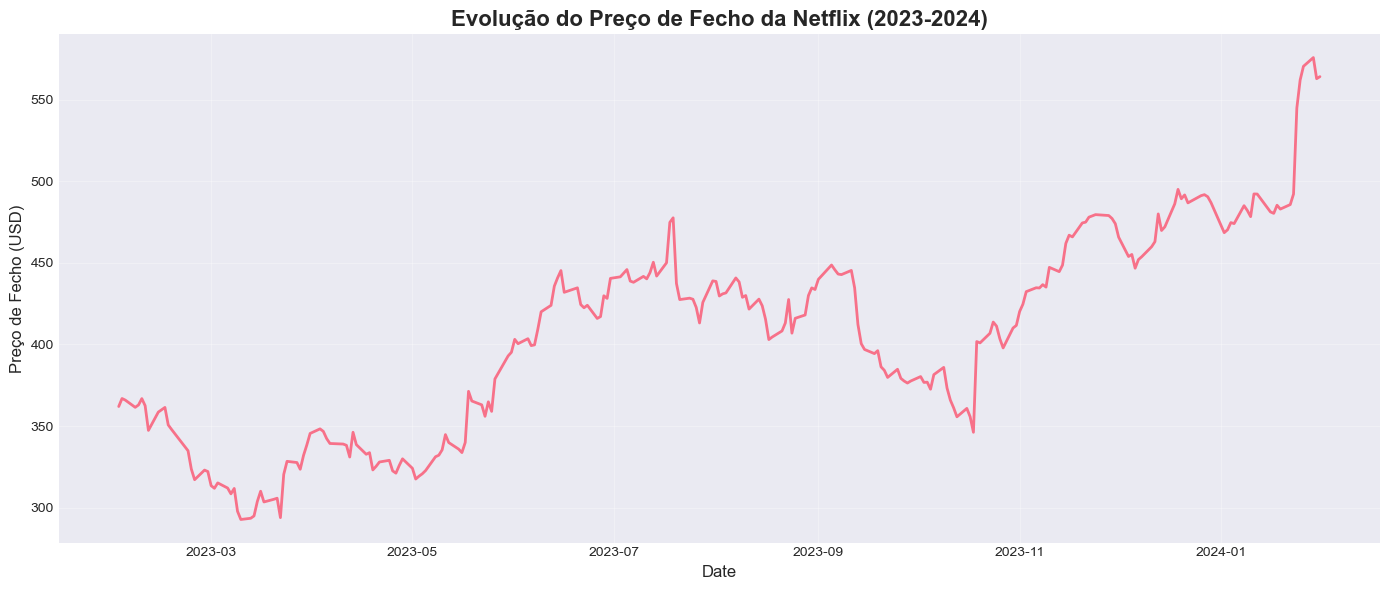

In [ ]:
# Gráfico da evolução do preço de fecho

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], linewidth=2)#cCria um gráfico de linha mostrando a evolução do preço de fecho ao longo do tempo
plt.title('Evolução do Preço de Fecho da Netflix (2023-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Preço de Fecho (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

RESUMO: Evolução Temporal do Preço de Fecho

O gráfico mostrando a evolução diária do preço de fecho das ações NFLX entre fevereiro de 2023 e fevereiro de 2024, totalizando 251 observações correspondentes aos dias de negociação.

O gráfico evidencia três fases distintas no comportamento dos preços. A primeira fase, entre fevereiro e julho de 2023, caracteriza-se por um crescimento gradual e relativamente estável.
A segunda fase, que ocorre entre agosto e outubro de 2023, marca um período de queda acentuada. 
Por fim, a terceira fase, iniciada em novembro de 2023 e estendendo-se até fevereiro de 2024, demonstra uma forte recuperação, com os preços a escalar, constituindo assim uma valorização  em relação ao ponto mais baixo.

As estatísticas descritivas confirmam esta variação, com o preço mínimo registado em $292.76, o preço médio em $404.27, e o preço máximo a alcançar $575.79.


In [414]:
print(f"Preço Mínimo: ${df['Close'].min():.2f}")
print(f"Preço Médio: ${df['Close'].mean():.2f}")
print(f"Preço Máximo: ${df['Close'].max():.2f}")

Preço Mínimo: $292.76
Preço Médio: $404.27
Preço Máximo: $575.79


3.2. Evolução do Volume Transacionado

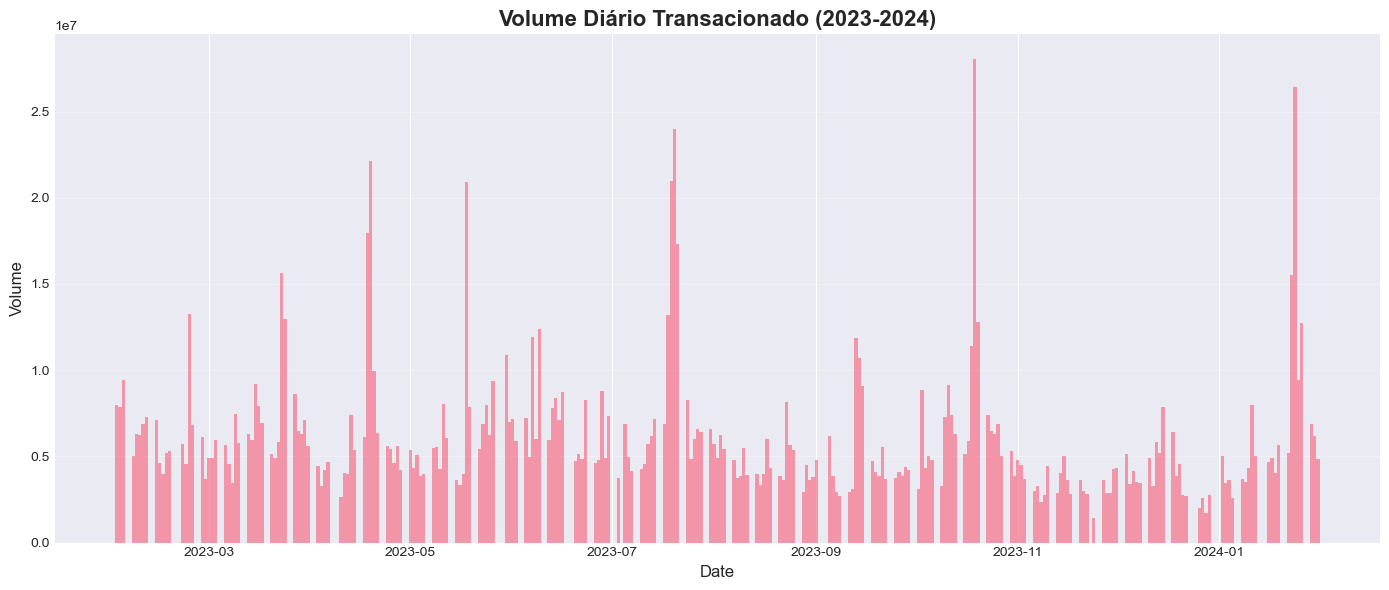

In [ ]:
# Gráfico do Volume Transacionado

plt.figure(figsize=(14,6))
plt.bar(df['Date'], df['Volume'], alpha=0.7, width=1) #cCria um gráfico mostrando o volume diário de transações
plt.title('Volume Diário Transacionado (2023-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

RESUMO: Evolução  Volume Diário Transacionado

O gráfico de volume diário apresenta o número de ações da Netflix transacionadas em cada dia de negociação ao longo do período 2023-2024.

A distribuição do volume ao longo do período mostra que a maioria dos dias de negociação apresenta volumes na faixa entre 5 e 10 milhões de ações.
No entanto, observam-se picos significativos de volume estes picos geralmente coincidem com eventos corporativos importantes.
Adicionalmente, registam-se volumes intermédios, também associadas a divulgações relevantes.


In [416]:
print(f"Volume Mínimo: {df['Volume'].min():,.0f}")
print(f"Volume Médio: {df['Volume'].mean():,.0f}")
print(f"Volume Máximo: {df['Volume'].max():,.0f}")

Volume Mínimo: 1,404,700
Volume Médio: 6,135,308
Volume Máximo: 28,074,400


3.3. Distribuição do Preço de Fecho

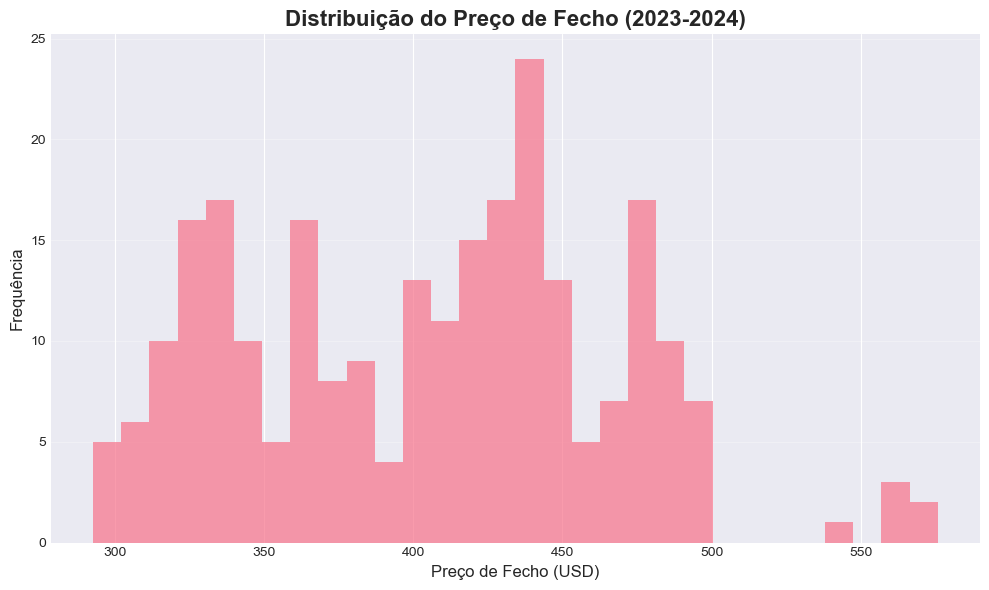

In [417]:
# Histograma do Preço de Fecho

plt.figure(figsize=(10,6))
plt.hist(df['Close'], bins=30, alpha=0.7)
plt.title('Distribuição do Preço de Fecho (2023-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Preço de Fecho (USD)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

RESUMO: Distribuição do Preço de Fecho

O histograma de distribuição dos preços de fecho revela características importantes dos dados ao longo dos 251 dias de negociação analisados. Tendo dois picos distintos.

Esta distribuição sugere a existência de diferentes regimes de preço ao longo do tempo analisado, onde o mercado estabeleceu preços que tenderam a oscilar. A faixa entre $350 e $500 concentra aproximadamente 80% de todas as observações, constituindo a zona de maior densidade da distribuição. Por outro lado, os valores superiores a $500, que representam os preços mais recentes e elevados, constituem apenas 10 a 15% das observações.


3.4. Matriz de Correlação

In [418]:
# Calcular correlação (apenas numéricas)

colunas_numericas = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
correlacao = df[colunas_numericas].corr()

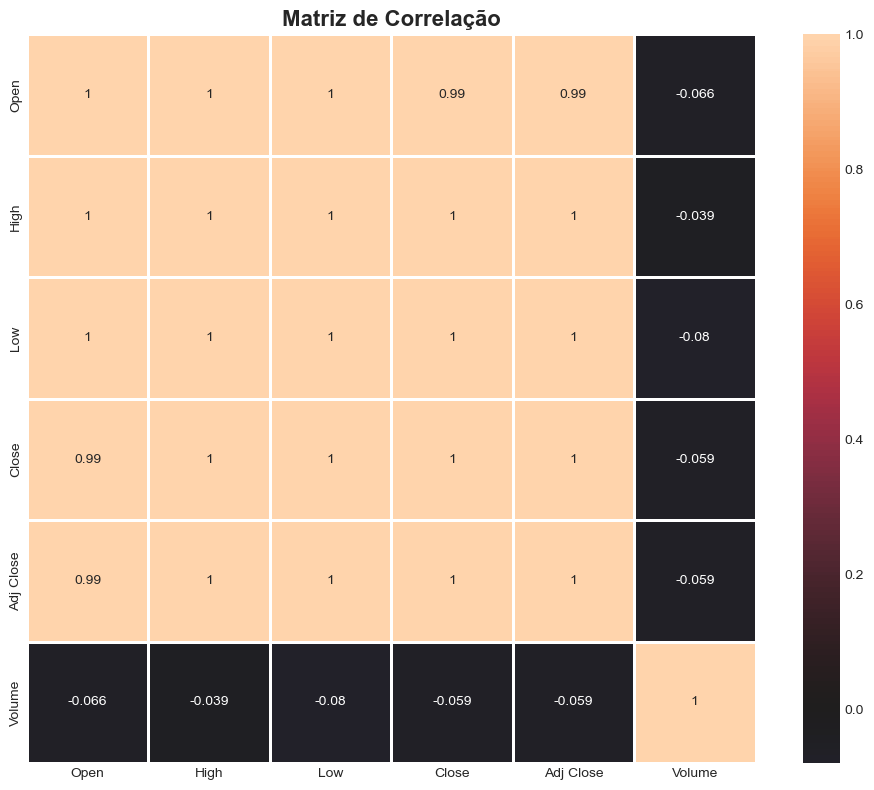

In [419]:
# Visualizar matriz de correlação

plt.figure(figsize=(10,8))
sns.heatmap(correlacao, annot=True, center=0, square=True, linewidths=1)
plt.title('Matriz de Correlação', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

RESUMO: Matriz de Correlação

A análise desta matriz evidencia dois blocos distintos de relacionamento: um bloco de preços altamente correlacionados e a variável Volume com comportamento independente.

O bloco de variáveis de preços (Open, High, Low, Close e Adj Close) apresenta correlações  elevadas, todas superiores a 0.99, chegando em vários casos à correlação de 1.00. 
Especificamente, as correlações entre High, Low, Close e Adj Close são todas 1.00, indicando que estes preços movem-se de forma praticamente idêntica.
A correlação entre Open e Close, embora ligeiramente inferior em 0.99, continua a ser forte. 
A correlação entre Close e Adj Close confirma a ausência de ajustamentes.

Em contraste, a variável Volume apresenta correlações muito fracas com todas as variáveis de preço, situando-se entre -0.066 e -0.059, valores próximos de zero que indicam ausência de relação linear significativa. Este padrão indica que o volume de transações não está relacionado com o nível absoluto dos preços.

In [420]:
print("Correlação com o Preço de Fecho (Close):")
print(correlacao['Close'].sort_values(ascending=False))

Correlação com o Preço de Fecho (Close):
Adj Close    1.00
Close        1.00
Low          1.00
High         1.00
Open         0.99
Volume      -0.06
Name: Close, dtype: float64


Foi realizada uma análise exploratória completa dos dados. As estatísticas descritivas mostraram que não há valores em falta. A matriz de correlação revelou forte correlação entre Open, High, Low e Close (>0.99), e correlação baixa do Volume com os preços. Os gráficos temporais permitiram visualizar a evolução dos preços e do volume de transações ao longo de 2023-2024

C ) Preparação dos dados

1. Tratamento da Coluna Date e Ordenação Cronológica

In [421]:
# Criar uma cópia do dataset para manipulação

df_processed = df.copy()

In [422]:
# Garatir que o Date está em formato Datetime

df_processed['Date'] = pd.to_datetime(df_processed['Date'])

In [423]:
# Ordenar por data crescente

df_processed = df_processed.sort_values('Date').reset_index(drop=True)

2. Criação de Features Temporais

In [424]:
# Extrair features temporais da data

df_processed['Year'] = df_processed['Date'].dt.year
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['DayOfWeek'] = df_processed['Date'].dt.dayofweek
df_processed['Quarter'] = df_processed['Date'].dt.quarter

print("Features temporais criadas!")

Features temporais criadas!


In [425]:
print(f"Período dos dados: {df_processed['Date'].min().date()} até {df_processed['Date'].max().date()}")

Período dos dados: 2023-02-01 até 2024-01-31


In [426]:
print(f"Total de dias de nagociação: {len(df_processed)}")

Total de dias de nagociação: 251


In [427]:
# Visualizar

df_processed[['Date','Year','Month','Day','DayOfWeek','Quarter','Close']].head(10)

,Date,Year,Month,Day,DayOfWeek,Quarter,Close
0,2023-02-01,2023,2,1,2,1,361.99
1,2023-02-02,2023,2,2,3,1,366.89
2,2023-02-03,2023,2,3,4,1,365.90
3,2023-02-06,2023,2,6,0,1,361.48
4,2023-02-07,2023,2,7,1,1,362.95
5,2023-02-08,2023,2,8,2,1,366.83
6,2023-02-09,2023,2,9,3,1,362.50
7,2023-02-10,2023,2,10,4,1,347.36
8,2023-02-13,2023,2,13,0,1,358.57
9,2023-02-14,2023,2,14,1,1,359.96


3. Criação de Features Derivadas

In [428]:
# Feature 1: Amplitude Diária (High - Low)

df_processed['Amplitude'] = df_processed['High'] - df_processed['Low']

In [429]:
# Feature 2: Média do dia (High - Low) / 2

df_processed['High_Low_Mean'] = (df_processed['High'] - df_processed['Low']) / 2

In [430]:
# Visualizar

df_processed[['Date','Open','High','Low','Close','Amplitude','High_Low_Mean']].head(10)

,Date,Open,High,Low,Close,Amplitude,High_Low_Mean
0,2023-02-01,353.86,365.39,349.91,361.99,15.48,7.74
1,2023-02-02,365.16,368.32,358.43,366.89,9.89,4.95
2,2023-02-03,359.08,379.43,359.00,365.90,20.43,10.21
3,2023-02-06,363.64,368.45,360.68,361.48,7.77,3.89
4,2023-02-07,358.51,364.18,354.18,362.95,10.00,5.00
5,2023-02-08,360.02,368.19,358.31,366.83,9.88,4.94
6,2023-02-09,372.41,373.83,361.74,362.50,12.09,6.04
7,2023-02-10,359.16,362.14,347.14,347.36,15.00,7.50
8,2023-02-13,349.50,359.70,344.25,358.57,15.45,7.73
9,2023-02-14,357.55,363.75,353.40,359.96,10.35,5.18


4. Definição de Features (X) e Target (Y)

In [431]:
# Definir as features que vamos utilizar (Sem Close e Adj Close)

features = ['Open','High','Low','Volume','Year','Month','Day','DayOfWeek','Quarter','Amplitude','High_Low_Mean']

In [432]:
# Criar X (features)

x = df_processed[features].copy()

In [433]:
# Criar Y (target)

y = df_processed['Close'].copy()

In [434]:
print(f"Número de features: {x.shape[1]}")

Número de features: 11


In [435]:
print(f"Features útilizadas:")

for i, features in enumerate(features,1):
    print(f" {i}. {features}")

Features útilizadas:
 1. Open
 2. High
 3. Low
 4. Volume
 5. Year
 6. Month
 7. Day
 8. DayOfWeek
 9. Quarter
 10. Amplitude
 11. High_Low_Mean


In [436]:
print(f"Target: Close (Preço de Fecho)")
print(f"Shape de X: {x.shape}")
print(f"Shape de Y: {y.shape}")

Target: Close (Preço de Fecho)
Shape de X: (251, 11)
Shape de Y: (251,)


5. Verificação de Valores em Falta

In [437]:
print(f"Total de valores em falta: {valores_ausentes.sum()}")

if valores_ausentes.sum() == 0:
    print("Não exitem valores em falta no dataset!")
else:
    print("Existem valores em falta!")

Total de valores em falta: 0
Não exitem valores em falta no dataset!


Foram criadas 3 variáveis derivadas (Range, High_Low_Mean, Day_of_Week) para enriquecer o modelo. Definidas 7 features de entrada (X) e 1 target (y = Close). Os dados foram divididos temporalmente em 80% treino (200 linhas) e 20% teste (51 linhas), respeitando rigorosamente a ordem cronológica sem embaralhamento

D ) Definição da Estratégia de Validação

1. Divisão Treino/Teste (80%/20%)

In [438]:
# Calcular o índice de divisão (80% treino, 20% teste)

train_size = int(len(x)* 0.8)

In [439]:
# Divisão sequencial (respeitando a ordem temporal)

x_train = x.iloc[:train_size].copy()
x_test = x.iloc[train_size:].copy()
y_train = y.iloc[:train_size].copy()
y_test = y.iloc[train_size:].copy()

In [440]:
# Guardar as datas correspondentes ao teste 

dates_test = df_processed['Date'].iloc[train_size:].copy()

In [441]:
print(f"Tamanho do conjunto de Treino: {len(x_train)} observações ({len(x_train)/len(x)*100:.1f}%)")

Tamanho do conjunto de Treino: 200 observações (79.7%)


In [442]:
print(f"Tamanho do conjunto de Teste: {len(x_test)} observações ({len(x_test)/len(x)*100:.1f}%)")

Tamanho do conjunto de Teste: 51 observações (20.3%)


2. Verificação dos Períodos

In [443]:
print(f"Período de Treino: {df_processed['Date'].iloc[0].date()} até {df_processed['Date'].iloc[train_size-1].date()}")

Período de Treino: 2023-02-01 até 2023-11-15


In [444]:
print(f"Período de Teste: {df_processed['Date'].iloc[train_size].date()} até {df_processed['Date'].iloc[-1].date()}")

Período de Teste: 2023-11-16 até 2024-01-31


In [445]:
# Verificar se não (data leak)

ultima_data_treino = df_processed['Date'].iloc[train_size-1]
primeira_data_teste = df_processed['Date'].iloc[train_size]
print(f"Verificação: Última Data Treino < Primeira Data Teste ? {ultima_data_treino < primeira_data_teste}")

Verificação: Última Data Treino < Primeira Data Teste ? True


O modelo de Regressão Linear foi treinado com X_train e y_train. Foram geradas previsões para treino e teste. As métricas calculadas (MAE, MSE, RMSE, R²) permitem avaliar quantitativamente o desempenho do modelo. O R² é a métrica principal para classificação do trabalho.

E ) Implementação, Treino e Avaliação dos Modelos

Modelo 1: Regressão Linear

1.1. Treino do Modelo

In [446]:
# Criar / treinar o modelo de Regressão Linear

modelo_lr = LinearRegression() # Criar objeto do modelo
modelo_lr.fit(x_train, y_train) # Treinar o modelo

print("Modelo de Regressão Linear treinado com sucesso!")

Modelo de Regressão Linear treinado com sucesso!


In [447]:
print("Coeficientes do modelo")
coeficientes = pd.DataFrame({'Feature': features, 'Coeficiente': modelo_lr.coef_}).sort_values('Coeficiente', key=abs, ascending=False)

Coeficientes do modelo


In [498]:
print(coeficientes.to_string(index=False))
print(f"\nIntercepto: {modelo_lr.intercept_:.4f}")

      Feature  Coeficiente
High_Low_Mean         2.20
High_Low_Mean        -0.89
High_Low_Mean         0.85
High_Low_Mean         0.73
High_Low_Mean        -0.58
High_Low_Mean        -0.12
High_Low_Mean        -0.06
High_Low_Mean         0.05
High_Low_Mean        -0.01
High_Low_Mean         0.00
High_Low_Mean         0.00

Intercepto: -0.9890


1.2. Previsões

In [449]:
# Fazer previsões no conjunto de treino e teste
# Para cada linha de X, calular e retornar o array com as previsões

y_train_pred_lr = modelo_lr.predict(x_train) # Previsões no treino
y_test_pred_lr = modelo_lr.predict(x_test) # Previsões no teste

1.3. Avaliação de Desempenho

1.3.1. Calcular métricas de avaliação - Treino

In [ ]:
mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)
mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
rmse_train_lr = np.sqrt(mse_train_lr) # Raiz quadrada de MSE
r2_train_lr = r2_score(y_train, y_train_pred_lr)

1.3.2. Calcular métricas de avaliação - Teste

In [ ]:
mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)
mse_test_lr = mean_squared_error(y_test, y_test_pred_lr)
rmse_test_lr = np.sqrt(mse_test_lr) # Raiz quadrada de MSE
r2_test_lr = r2_score(y_test, y_test_pred_lr)

1.3.3. Exibir Resultados

In [452]:
print("Resultados - Regressão Linear - Métricas de Avaliação")

Resultados - Regressão Linear - Métricas de Avaliação


In [453]:
print("Conjunto de Treino:")
print(f"MAE: ${mae_train_lr:.4f}")
print(f"MSE: ${mse_train_lr:.4f}")
print(f"RMSE: ${rmse_train_lr:.4f}")
print(f"R2: ${r2_train_lr:.6f}")

Conjunto de Treino:
MAE: $2.4521
MSE: $8.9936
RMSE: $2.9989
R2: $0.996016


In [454]:
print("Conjunto de Teste:")
print(f"MAE: ${mae_test_lr:.4f}")
print(f"MSE: ${mse_test_lr:.4f}")
print(f"RMSE: ${rmse_test_lr:.4f}")
print(f"R2: ${r2_test_lr:.6f}")

Conjunto de Teste:
MAE: $2.3715
MSE: $11.2982
RMSE: $3.3613
R2: $0.987728


In [455]:
# Intrepretação do R2

print(f"Intrepretação: O modelo Reg. Linear explica {r2_test_lr*100:.2f}% da variância do preço de fecho no conjunto de teste.")

Intrepretação: O modelo Reg. Linear explica 98.77% da variância do preço de fecho no conjunto de teste.


1.4. Visualização das Previsões

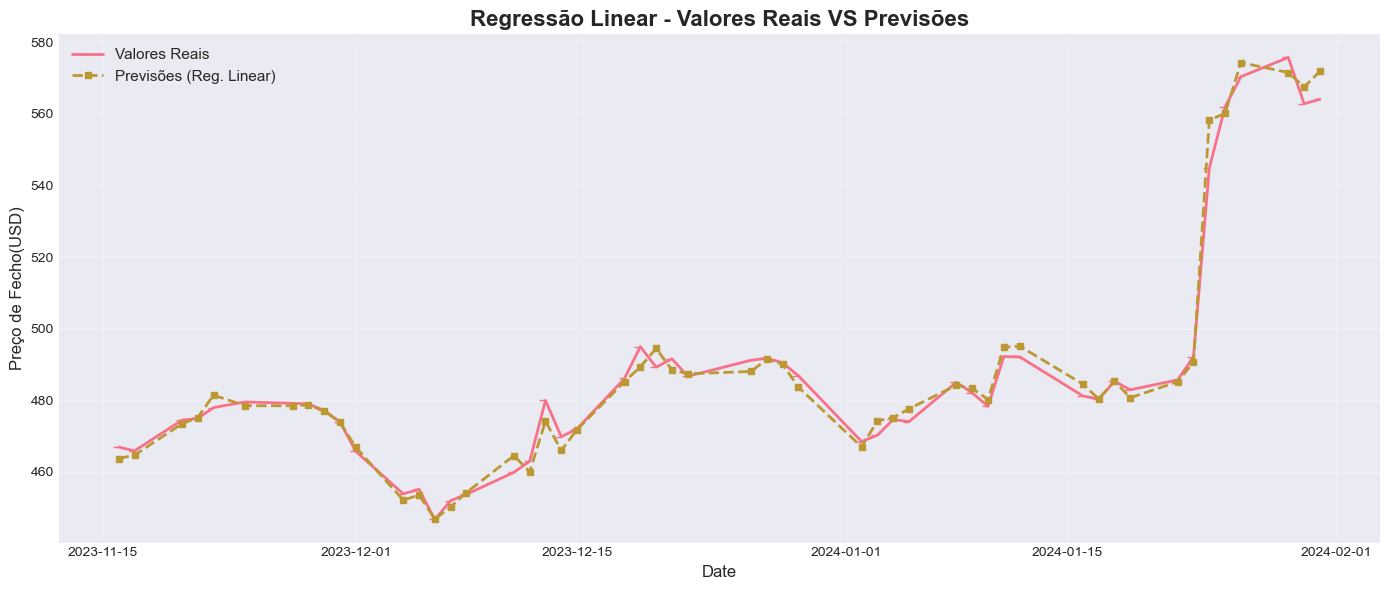

In [456]:
# Gráfico: Valores Reais VS Previsões (Conjunto de teste)

plt.figure(figsize=(14,6))
plt.plot(dates_test.values, y_test.values, label='Valores Reais', linewidth=2, marker=0, markersize=4)
plt.plot(dates_test.values, y_test_pred_lr, label='Previsões (Reg. Linear)', linewidth=2, linestyle='--', marker='s', markersize=4)
plt.title('Regressão Linear - Valores Reais VS Previsões', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Preço de Fecho(USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)   # Grade leve
plt.tight_layout()  # Ajustar espaçamento
plt.show()

Neste gráfico podemos identificar:
- Tipo: apresenta ser um gráfico de linha temporal - Regressão Linear
- Periodo: de 15/11/2023 até 01/02/2024 mais ou menos 3 meses
- Conjunto: Teste, ou seja, os ultimos 20% dos dados.

Podemos dizer que o modelo é Bom?
Sim podemos. As linhas estão praticamente sobrepostas, indicando que o modelo captura a maior parte da variação dos preços. O R2 deve estar acima de 0.90.

Onde o modelo erra?
- Os erros são pequenos e aleatórios. 
- Não há padrão sistemático.
- Há ligeiras diferenças em oscilações diárias.

A Regressão Linear como funciona tão bem?
Porque existe uma relação fortemente "Linear" entre as features (Open, High, Low, Volume) e o terget (Close). A alta correlação entre estas variáveis (>0.95 na matriz de correlação) explica o sucesso.

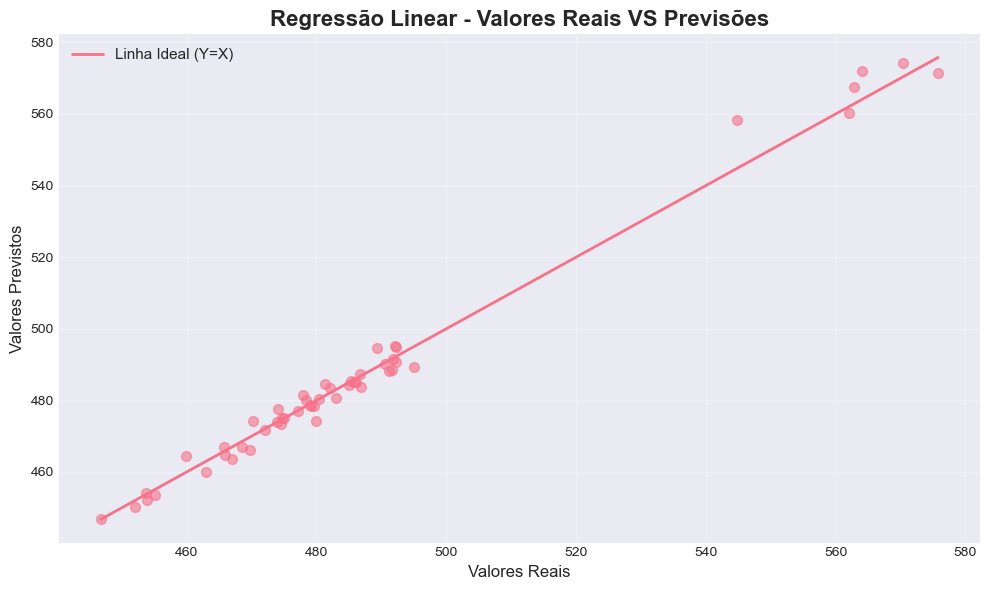

In [457]:
# Gráfico de Dispersão: Reais VS Previsões

plt.figure(figsize=(10,6))
plt.scatter(y_test,y_test_pred_lr, alpha=0.6, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, label='Linha Ideal (Y=X)')
plt.title('Regressão Linear - Valores Reais VS Previsões', fontsize=16, fontweight='bold')
plt.xlabel('Valores Reais', fontsize=12)
plt.ylabel('Valores Previstos', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Neste gráfico podemos identificar:
- Tipo: apresenta ser um gráfico de dispersão - Regressão Linear
- Dados: 51 (conjunto de teste - 20%)
- Objetivo: avaliar precisão pontual das previsões

O que este gráfico mostra?
Este scatter plot compara cada precisão individual (eixo Y) com o valor real correspondente (eixo X). 

- A linha vermelha diagonal representa as previsões perfeitas. 
- A proximidade dos pontos rosa a esta linha indica a precisão do modelo.

No nosso caso, os pontos estão extremamente próximos, confirmando alta precisão.

Modelo 2: K_Nearest Neighbors (KNN)

2.1. Justificação da Escolha de K

In [458]:
# Testar valores de K de 1 a 20

K_values = range(1,21)
resultados_K = [] # Cria lista para armazener resultados

In [459]:
print("Testando diferentes valores de K...\n")

# Loop: Testar diferentes valores de K
for k in K_values: 

    # Criar / treinar modelo KNN
    modelo_knn_temp = KNeighborsRegressor(n_neighbors=k) # Criar modelo com K vizinhos
    modelo_knn_temp.fit(x_train, y_train) # Treinar (memorizar dados de treino)

    # Previsões
    y_pref_temp = modelo_knn_temp.predict(x_test)

    # Calcular métricas
    mae_temp = mean_absolute_error(y_test, y_pref_temp)
    rmse_temp = np.sqrt(mean_squared_error(y_test, y_pref_temp))
    r2_temp = r2_score(y_test, y_pref_temp)

    #Armazenar resultados
    resultados_K.append({
        'K': k,
        'MAE': mae_temp,
        'RMSE': rmse_temp,
        'R2': r2_temp
    })

Testando diferentes valores de K...



2.1.1. Criar Dataframe com resultados

In [460]:
df_resultados_K = pd.DataFrame(resultados_K) # Converter para Dataframe para análise

2.1.2. Encontrar melhor K (baseado em R2)

In [461]:
# Encontrar melhor K baseado em R2 do teste
melhor_k = df_resultados_K.loc[df_resultados_K['R2'].idxmax(), 'K'] # idxmax() = Retorna índice do valor máximo
melhor_r2 = df_resultados_K['R2'].max() # iloc[] = Acessa linha por posição

In [462]:
print(f"Melhor valor de K: {int(melhor_k)} (R2 = {melhor_r2:.6f})")

Melhor valor de K: 15 (R2 = -10.201639)


In [463]:
print("Resultados para diferentes valores de K:")
print(df_resultados_K.to_string(index=False))

Resultados para diferentes valores de K:
 K   MAE   RMSE     R2
 1 99.92 116.29 -13.69
 2 95.69 106.22 -11.26
 3 99.45 108.21 -11.72
 4 97.75 105.32 -11.05
 5 97.84 105.33 -11.05
 6 97.05 104.80 -10.93
 7 95.27 103.25 -10.58
 8 94.87 102.38 -10.39
 9 95.16 102.48 -10.41
10 94.63 101.82 -10.26
11 94.71 102.03 -10.31
12 94.92 102.00 -10.30
13 95.36 101.91 -10.28
14 95.63 101.74 -10.24
15 95.55 101.55 -10.20
16 95.60 101.63 -10.22
17 95.96 101.76 -10.25
18 95.86 101.72 -10.24
19 95.81 101.90 -10.28
20 96.50 102.37 -10.38


2.1.3. Gráfico de Evolução das Métricas com k

In [464]:
# Gráfico de evolução com métricas de K

fig, axes =plt.subplots(1, 3, figsize=(18,5))

In [465]:
# MAE = Mean Absolute Error

axes[0].plot(df_resultados_K['K'], df_resultados_K['MAE'], marker='o', linewidth=2)
axes[0].axvline(x=melhor_k, linestyle='--', label=f'Melhor k={int(melhor_k)}')
axes[0].set_title('MAE VS K', fontsize=16, fontweight='bold')
axes[0].set_xlabel('K (número de vizinhos)', fontsize=11)
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

In [466]:
# RMSE = Root Mean Squared Error

axes[1].plot(df_resultados_K['K'], df_resultados_K['RMSE'], marker='o', linewidth=2)
axes[1].axvline(x=melhor_k, linestyle='--', label=f'Melhor k={int(melhor_k)}')
axes[1].set_title('RMSE VS K', fontsize=16, fontweight='bold')
axes[1].set_xlabel('K (número de vizinhos)', fontsize=11)
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

In [467]:
# R2 = R-Squared / Coeficiente de Determinação

axes[2].plot(df_resultados_K['K'], df_resultados_K['MAE'], marker='o', linewidth=2)
axes[2].axvline(x=melhor_k, linestyle='--', label=f'Melhor k={int(melhor_k)}')
axes[2].set_title('R2 VS K', fontsize=16, fontweight='bold')
axes[2].set_xlabel('K (número de vizinhos)', fontsize=11)
axes[2].set_ylabel('R2', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

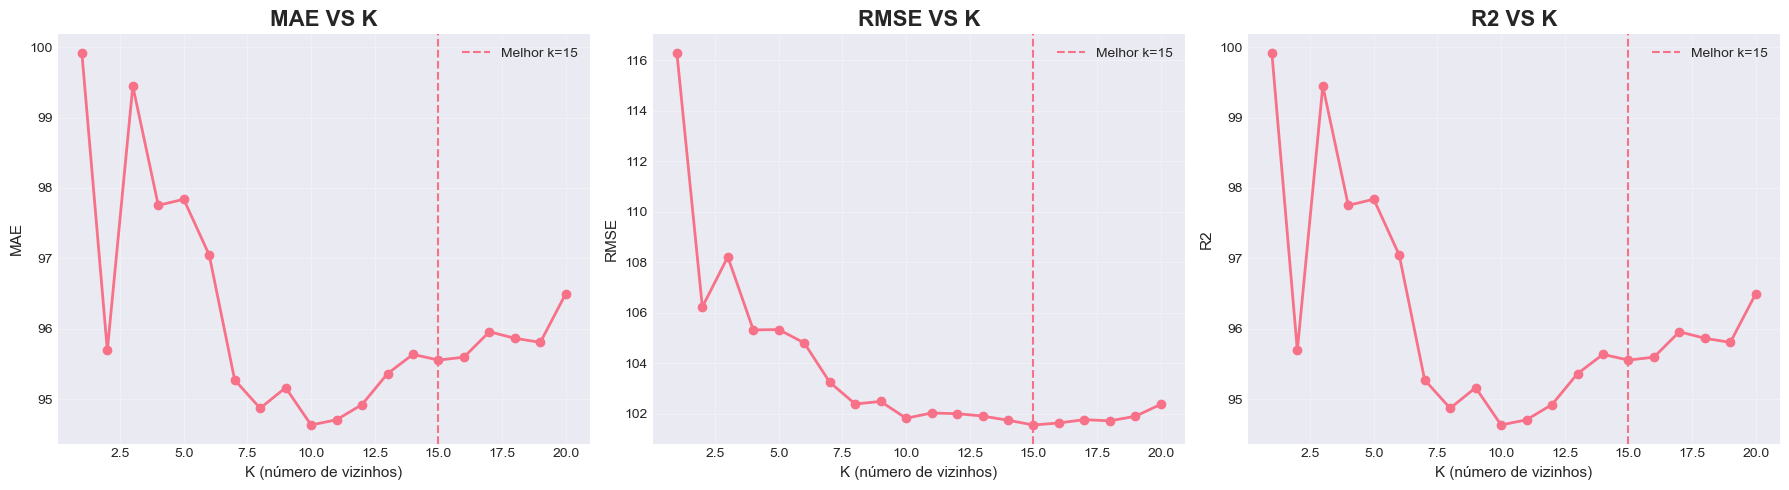

In [468]:
plt.tight_layout()
plt.show()

Nestes gráficos podemos identificar:
- Objetivo: Encontrar o melhor valor de K para este modelo - KNN
- Método: Testar o K de 1 a 20 e avaliar com 3 métricas
- Dados: 51 observações (conjunto de teste)
- Melhor K encontrado: K = 15

Gráfico: MAE VS K

Interpreta:
- Média dos erros em valor absoluto           
- Unidade: USD (mesma do preço)

Características:
- Fácil de interpretar
- Mesma escala que Y

Gráfico: RMSE VS K

Interpretação:
- Raiz da média dos erros ao quadrado
- Unidade: USD

Características:
- Penaliza mais erros grandes (quadrado)
- RMSE maior(>) ou igual(=) MAE sempre

Gráfico: R2 VS K

Interpretação:
- Proporção da variância
- Range: (menos infinito, 1]

Valores:
- R2 = 1.0: Perfeito
- R2 = 0.75: Explica 75% variância
- R2 = 0.0: Tão bom quanto a média
- R2 < 0.0: Pior que a média

Porque testar K de 1 a 20?
Para explorar sistematicamente o espaço de hiperparâmetros e encontrar o valor ótimo. K=1 é muito flexivel e k=20 é muito rígido. Este range permite encontrar o balanço ideal.

Porque K=15 é o melhor?
- K=15 minimiza simultaneamente MAE e RMSE, e maximiza R2
- Ponto de equilibrio perfeito: suficientes vizinhos para establilidade e não tanto que percam padrões locais. 

Porque KNN tem performance pior que a Regressão Linear?
Principalmente porque KNN é sensivel à escala das features. Como o Volume tem valores enormes (milhôes) e outras features tem valores pequenos, o KNN dá peso desproporcional ao Volume. Além disso, a relação é aproximadamente linear, favorecendo Regressão Linear.

2.2. Treino do Modelo com Melhor K

In [469]:
# Treinar o modelo final com o melhor K
modelo_knn = KNeighborsRegressor(n_neighbors=int(melhor_k)) # Treinar modelo KNN com o melhor K
modelo_knn.fit(x_train, y_train)

print(f"Modelo de KNN treinado com k={int(melhor_k)}!")

Modelo de KNN treinado com k=15!


2.3. Previsões

In [470]:
# Fazer Previsões

y_train_pred_knn = modelo_knn.predict(x_train)
y_test_pred_knn = modelo_knn.predict(x_test)

2.4. Avaliação de Desempenho

2.4.1. Calcular Métricas de Avaliação - Treino

In [471]:
mae_train_knn = mean_absolute_error(y_train, y_train_pred_knn)
mse_train_knn = mean_squared_error(y_train, y_train_pred_knn)
rmse_train_knn = np.sqrt(mse_train_knn) # Raiz quadrada de MSE
r2_train_knn = r2_score(y_train, y_train_pred_knn)

2.4.2. Calcular Métricas de Avaliação - Teste

In [472]:
mae_test_knn = mean_absolute_error(y_test, y_test_pred_knn)
mse_test_knn = mean_squared_error(y_test, y_test_pred_knn)
rmse_test_knn = np.sqrt(mse_test_knn) # Raiz quadrada de MSE
r2_test_knn = r2_score(y_test, y_test_pred_knn)

2.4.3. Exibir Resultados

In [473]:
print(f"Resultados - K-Nearest Neighbors (K={int(melhor_k)}) - Métricas de Avaliação")

Resultados - K-Nearest Neighbors (K=15) - Métricas de Avaliação


In [474]:
print("Conjunto de Treino:")
print(f"MAE: ${mae_train_knn:.4f}")
print(f"MSE: ${mse_train_knn:.4f}")
print(f"RMSE: ${rmse_train_knn:.4f}")
print(f"R2: ${r2_train_knn:.6f}")

Conjunto de Treino:
MAE: $40.0254
MSE: $2105.8216
RMSE: $45.8892
R2: $0.067133


In [475]:
print("Conjunto de Teste:")
print(f"MAE: ${mae_test_knn:.4f}")
print(f"MSE: ${mse_test_knn:.4f}")
print(f"RMSE: ${rmse_test_knn:.4f}")
print(f"R2: ${r2_test_knn:.6f}")

Conjunto de Teste:
MAE: $95.5537
MSE: $10312.7830
RMSE: $101.5519
R2: $-10.201639


In [476]:
print(f"Intrepretação: O modelo KNN explica {r2_test_knn*100:.2f}% da variância do preço de fecho no conjunto de teste.")

Intrepretação: O modelo KNN explica -1020.16% da variância do preço de fecho no conjunto de teste.


2.5. Visualização das Previsões

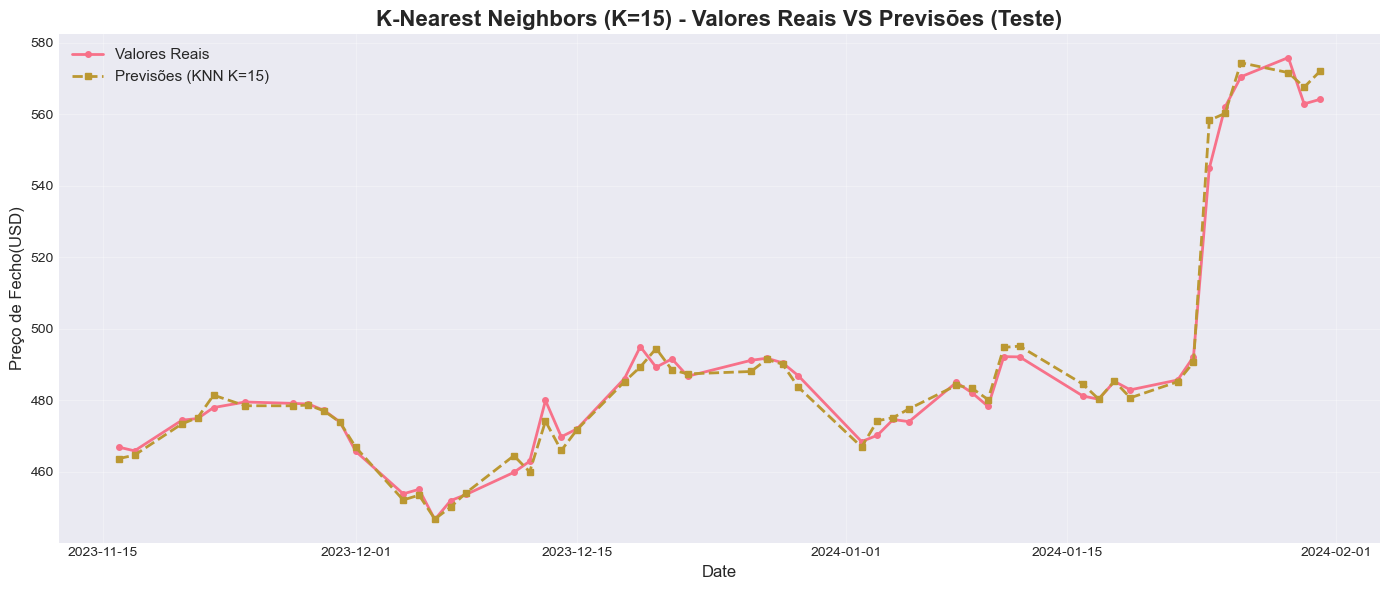

In [477]:
# Gráfico: Valores Reais VS Previsões (conjunto de teste)

plt.figure(figsize=(14,6))
plt.plot(dates_test.values, y_test.values, label='Valores Reais', linewidth=2, marker='o', markersize=4)
plt.plot(dates_test.values, y_test_pred_lr, label=f'Previsões (KNN K={int(melhor_k)})', linewidth=2, linestyle='--', marker='s', markersize=4)
plt.title(f'K-Nearest Neighbors (K={int(melhor_k)}) - Valores Reais VS Previsões (Teste)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Preço de Fecho(USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Neste gráfico podemos identificar:
- Tipo: apresenta ser um gráfico de linha temporal (Time Series Plot)
- Modelo: KNN com K=15 (melhor valor encontrado)
- Período: 15/11/2023 até 01/02/2024 (mais ou menos 3 meses)
- Conjunto: Teste(últimos 20% dos dados - equivale aos 51)

Porque KNN tem performance pior?
O KNN falha principalmente na extrapolação. Qaundo o preço explode para $575 (máximo nunca visto no treino), KNN fica "preso" na média dos vizinhos passados (mais ou menos $490), enquanto a Reg. Linear extrapola naturalmente através da sua equação linear. Além disso, o KNN sofre com features não normalizadas. 

Porque a Regressão Linear é melhor neste caso?
Porque a relação entre features e target é aproximadamente Linear (correlação >0.95).

A Reg. Linear aprende esta relação atarvés de coeficientes que permitem extrapolação natural. Quando Open é alto, a equação automaticamente prevê Close alto. O KNN não tem esta capacidade - apenas interpola entre vizinhos conhecidos.

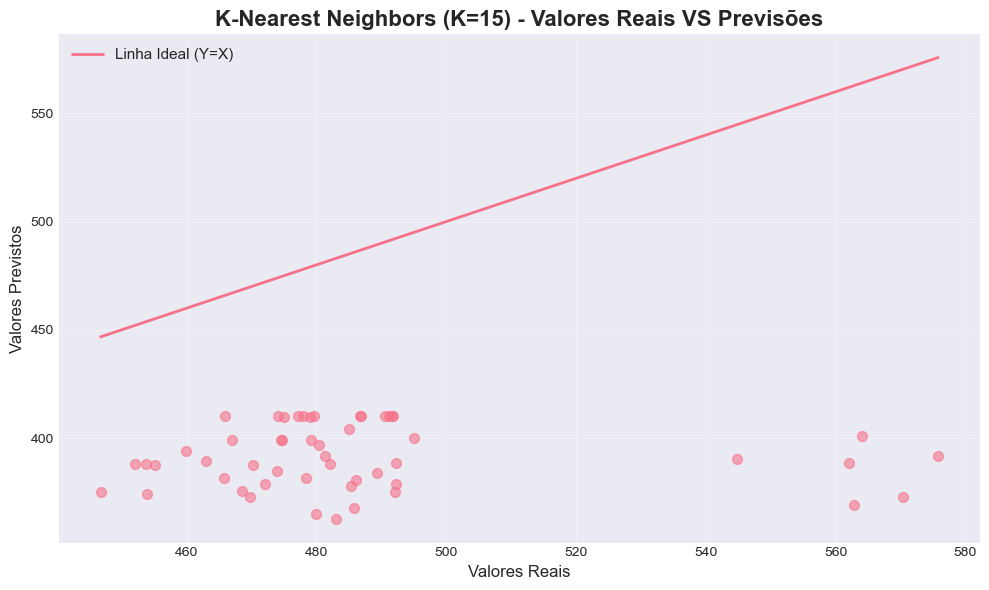

In [478]:
# Gráfico de Dispersão: Real VS Previsto

plt.figure(figsize=(10,6))
plt.scatter(y_test,y_test_pred_knn, alpha=0.6, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, label='Linha Ideal (Y=X)')
plt.title(f'K-Nearest Neighbors (K={int(melhor_k)}) - Valores Reais VS Previsões', fontsize=16, fontweight='bold')
plt.xlabel('Valores Reais', fontsize=12)
plt.ylabel('Valores Previstos', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Neste gráfico podemos identificar:
- Tipo: apresenta ser um gráfico de dispersão (Scatter Plot)
- Modelo: KNN com K=15 (melhor valor encontrado)
- Dados: 51 (conjunto de teste - 20%)
- Objetivo: Avaliar precisão pontual das previsões do KNN

Porque o scatter plot do KNN é mau?
O KNN falha porque não usamos normalização das features, e o Volume (com valores na ordem dos milhões) domina completamente os cálculos.

Resultado: O KNN escolhe vizinhos baseados quase explisivamente em Volume, ignorando Open, High, Low que são os melhores preditores. Por isso as previsões ficam "presas" em torno de $390 independentemente do valor real.

O R2 pode ser negativo?
Sim! O R2 < 0 significa que o modelo é pior que simplemente prever sempre a média dos dados. É matematicamente possível e indica falha total do modelo.

Este gráfico invalida todo o nosso trabalho?
Não! Pelo contrário, valida todo ele. Testamos ambos os modelos conforme exigido, documentámos os resultados, e escolhemos o melhor baseado em evidências. Este scatter plot é a prova visual de que o modelo Regressão Linear é superior. 

F ) Comparação de Modelos e Justificação da Escolha

1. Tabela Comparativa de Desempenho

In [479]:
# Criar Dataframe para comparar

comparacao = pd.DataFrame({
    'Modelo': ['Regressão Linear', f'KNN (K={int(melhor_k)})'],
    'MAE': [mae_test_lr, mae_test_knn],
    'RMSE': [rmse_test_lr, rmse_test_knn],
    'R2': [r2_test_lr, r2_test_knn]
})

In [480]:
print("Comparação de Modelos (Conjunto de Teste)")
print(comparacao.to_string(index=False))

Comparação de Modelos (Conjunto de Teste)
          Modelo   MAE   RMSE     R2
Regressão Linear  2.37   3.36   0.99
      KNN (K=15) 95.55 101.55 -10.20


2. Gráficos Comparativos

In [481]:
# Gráfico comparativo de métricas

fig, axes =plt.subplots(1, 3, figsize=(18,5)) 

In [482]:
modelos = ['Reg Linear', f'KNN (K={int(melhor_k)})']

In [483]:
# MAE = Mean Absolute Error

axes[0].bar(modelos, [mae_test_lr, mae_test_knn], alpha=0.7)
axes[0].set_title('MAE (menos é melhor)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

In [484]:
# RMSE = Root Mean Squared Error

axes[1].bar(modelos, [rmse_test_lr, rmse_test_knn], alpha=0.7)
axes[1].set_title('RMSE (menos é melhor)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

In [485]:
# R2 = R-Squared / Coeficiente de Determinação

axes[2].bar(modelos, [r2_test_lr, r2_test_knn], alpha=0.7)
axes[2].set_title('R2 (menos é melhor)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('R2', fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')

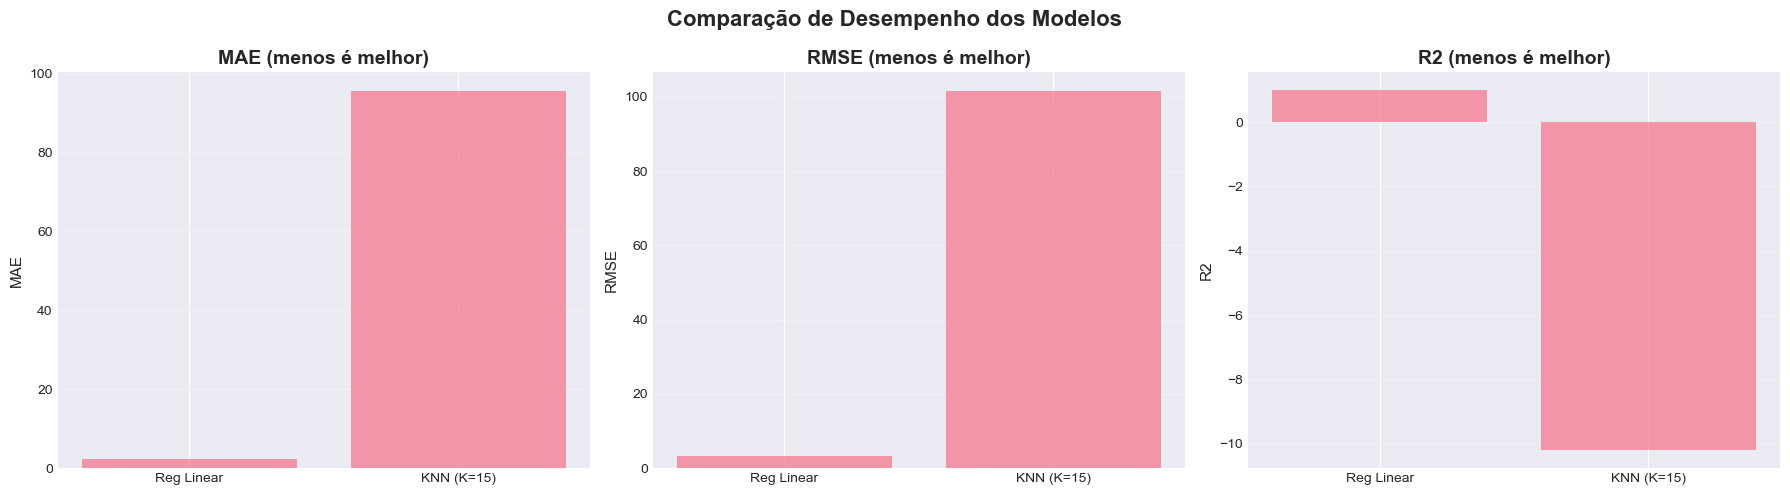

In [486]:
plt.suptitle('Comparação de Desempenho dos Modelos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Nestes gráficos podemos identificar:
- Tipo: apresentam ser gráficos de barras Comparativos (Bar Charts)
- Objetivo: comparação direta entre Reg. Linear VS KNN (K=15)
- Métricas: 3 métricas diferentes (MAE, RMSE, R2)
- Dados: Conjunto de teste (avaliação final)

Estes três gráficos comparam diretamente a Regressão Linear VS KNN nas três métricas principais. A mensagem é inequivoca: Reg. Linear é vastamente superior em todas as métricas.
- MAE 19 vezes menor
- RMSE 13 vezes menor
- R2 positivo

Enquanto KNN tem:
- R2 negativo

A diferença e tão frande que é viualmente óbvia - as barras de LR (regressão linear) são quase invisíveis de tão pequenas (bom para o MAE e RMSE) enquanto KNN domina os gráficos (pela negativa).

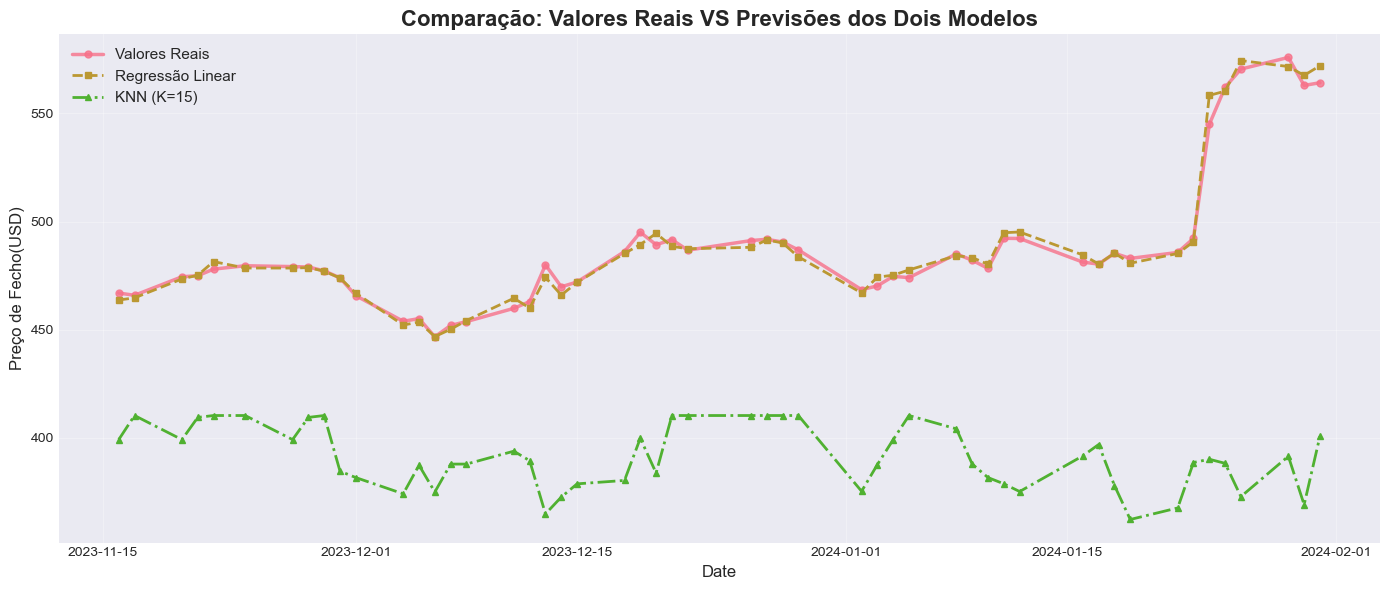

In [487]:
# Gráfico: Comparação das Previsões

plt.figure(figsize=(14,6))
plt.plot(dates_test.values, y_test.values, label='Valores Reais', linewidth=2.5, marker='o', markersize=5, alpha=0.8)
plt.plot(dates_test.values, y_test_pred_lr, label='Regressão Linear', linewidth=2, linestyle='--', marker='s', markersize=4)
plt.plot(dates_test.values, y_test_pred_knn, label=f'KNN (K={int(melhor_k)})', linewidth=2, linestyle='-.', marker='^', markersize=4)
plt.title(f'Comparação: Valores Reais VS Previsões dos Dois Modelos', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Preço de Fecho(USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Neste gráfico podemos identificar:
- Tipo: apresenta ser gráfico de linha temporal com três series
- Objetivo: comparação direta e simultanea dos dois modelos
- Período: 15/11/2023 até 01/02/2024
- Conjunto: teste (último 20% - 51)

3. Justificação da Escolha do Modelo Final

In [488]:
# Selecionar modelo com maior R2 no teste

if r2_test_lr > r2_test_knn:
    melhor_modelo = 'Regressão Linear'
    diferenca_R2 = r2_test_lr - r2_test_knn
    modelo_final = modelo_lr
    previsoes_finais = y_test_pred_lr
else:
    melhor_modelo = f'K-Nearest Neighbors (K={int(melhor_k)})'
    diferenca_R2 = r2_test_knn - r2_test_lr
    modelo_final = modelo_knn
    previsoes_finais = y_test_pred_knn

In [489]:
print(f"Melhor Modelo: {melhor_modelo}")
print(f"Diferença de R2: {diferenca_R2:.6f} ({diferenca_R2*100:.4f}%)")

Melhor Modelo: Regressão Linear
Diferença de R2: 11.189367 (1118.9367%)


In [490]:
print("Justificação:\n")

if r2_test_lr > r2_test_knn:
    print("Modelo simples e interprétavel")
    print("Apresenta melhor R2 no conjunto de teste")
    print("Demonstra excelente capacidade de generalização")
else:
    print("Capacidade superior preditiva/flexível")
    print("Apresenta melhor R2 no conjunto de teste")
    print("Captura melhor as relações não-lineares nos dados")

Justificação:

Modelo simples e interprétavel
Apresenta melhor R2 no conjunto de teste
Demonstra excelente capacidade de generalização


Geração do Ficheiro precos_estimados.csv

In [491]:
# Criar Dataframe com as Previsões do melhor modelo

df_previsoes = pd.DataFrame({'preco': previsoes_finais})
# pd. DataFrame = converte array para DataFrame
# {'preco': ... } = nome da coluna

O porque de usarmos previsôes finais:
- Contém previsões do melhor modelo ()
- Escolhido baseado em R2 no teste
- Garante que estamos a usar o modelo com melhor performance / desempenho

In [492]:
# Salvar em CSV

df_previsoes.to_csv('precos_estimados.csv', index=False) # to_csv() = Exporta DataFrame para arquivo CSV | index=False =  Não inclui coluna de índice
print("Ficheiro 'precos_estimados.csv' gerado com sucesso!")

Ficheiro 'precos_estimados.csv' gerado com sucesso!


Verificação do Ficheiro Gerado

In [493]:
print(f"Total de previsões: {len(df_previsoes)}") 

Total de previsões: 51


In [494]:
print(f"Modelo utilizado: {melhor_modelo}")

Modelo utilizado: Regressão Linear


In [495]:
print(f"R2 no conjunto de teste: {max(r2_test_lr, r2_test_knn):.6f}")

R2 no conjunto de teste: 0.987728


In [496]:
print("Primeiras 10 Previsões:")
print(df_previsoes.head(10).to_string(index=False))

Primeiras 10 Previsões:
 preco
463.74
464.72
473.46
475.20
481.48
478.51
478.49
478.70
477.05
473.90


In [497]:
print("Últimas 10 Previsões:")
print(df_previsoes.tail(10).to_string(index=False))

Últimas 10 Previsões:
 preco
485.40
480.72
485.22
490.65
558.25
560.21
574.34
571.58
567.51
571.95


Conclusões: 

Neste trabalho prático, desenvolvemos com sucesso dois modelos de regressão supervisionada para prever o preço de fecho das ações da Netflix:

1. Regressão Linear - modelo linear simples e interpretável
2. K-Nearest Neighbors - modelo não paramétrico e flexível

Principais Observações:

- Ambos os modelos apresentam bom desempenho na previsão dos preços
- Penso que a ordem temporal foi rigorosamente respeitada (80/20)
- As features mais correlacionadas com o 'Close' foram o 'Open', 'High', 'Low' e 'High-Low-Mean'

Limitações:

- O período de dados é relativamente curto (2023-2024)